# Random Forest Prediction of Laser Ablation Depth

This notebook rebuilds the random forest part of my undergraduate project. The inputs are laser voltage and pulse count, and the target is the measured maximum ablation depth.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import (
    GridSearchCV, GroupKFold, KFold, cross_validate, train_test_split
)
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 120
random_state = 42

root = Path.cwd()
if not (root / 'data' / 'ablation_data.csv').exists():
    root = root.parent
figure_dir = root / 'figures'
result_dir = root / 'results'
figure_dir.mkdir(exist_ok=True)
result_dir.mkdir(exist_ok=True)

Matplotlib is building the font cache; this may take a moment.


## 1. Data

The dataset contains 120 measurements from an 8 × 15 voltage-pulse grid. Laser power is not used together with voltage because it is calculated directly from voltage and would duplicate the same input information.

In [2]:
data = pd.read_csv(root / 'data' / 'ablation_data.csv')
features = ['voltage_V', 'pulses']
target = 'depth_um'
data[features + [target]].head()

,voltage_V,pulses,depth_um
0,460,10,11.1502
1,460,20,11.3838
2,460,30,14.4907
3,460,40,15.0517
4,460,50,16.6306


In [3]:
data_check = pd.Series({
    'rows': len(data),
    'missing_values': data[features + [target]].isna().sum().sum(),
    'duplicate_settings': data.duplicated(features).sum(),
    'minimum_depth_um': data[target].min(),
    'maximum_depth_um': data[target].max(),
})
data_check

rows                  120.0000
missing_values          0.0000
duplicate_settings      0.0000
minimum_depth_um       11.1502
maximum_depth_um       31.9041
dtype: float64

## 2. Train-test split and baseline models

The 80/20 split and random seed follow the thesis. Model selection is carried out only on the training set, so the test set remains independent until the final comparison.

In [4]:
X = data[features]
y = data[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=random_state
)
print(f'Training samples: {len(X_train)}')
print(f'Test samples: {len(X_test)}')

Training samples: 96
Test samples: 24


In [5]:
models = {
    'Mean baseline': DummyRegressor(strategy='mean'),
    'Linear regression': LinearRegression(),
    'Quadratic regression': make_pipeline(
        PolynomialFeatures(degree=2, include_bias=False),
        LinearRegression(),
    ),
    'Reference random forest': RandomForestRegressor(
        n_estimators=100,
        max_depth=15,
        min_samples_split=2,
        min_samples_leaf=1,
        random_state=random_state,
        n_jobs=-1,
    ),
}

cv = KFold(n_splits=5, shuffle=True, random_state=random_state)
scoring = {
    'r2': 'r2',
    'mae': 'neg_mean_absolute_error',
    'rmse': 'neg_root_mean_squared_error',
}

In [6]:
cv_rows = []
for name, model in models.items():
    scores = cross_validate(model, X_train, y_train, cv=cv, scoring=scoring)
    cv_rows.append({
        'model': name,
        'R2_mean': scores['test_r2'].mean(),
        'R2_std': scores['test_r2'].std(),
        'MAE_mean_um': -scores['test_mae'].mean(),
        'RMSE_mean_um': -scores['test_rmse'].mean(),
    })

cv_results = pd.DataFrame(cv_rows).sort_values('RMSE_mean_um')
cv_results.to_csv(result_dir / 'cv_model_comparison.csv', index=False)
cv_results.round(4)

,model,R2_mean,R2_std,MAE_mean_um,RMSE_mean_um
3,Reference random forest,0.9711,0.0039,0.6046,0.7943
2,Quadratic regression,0.9674,0.0070,0.6590,0.8407
1,Linear regression,0.9469,0.0126,0.7971,1.0715
0,Mean baseline,-0.0791,0.0926,4.1450,4.8827


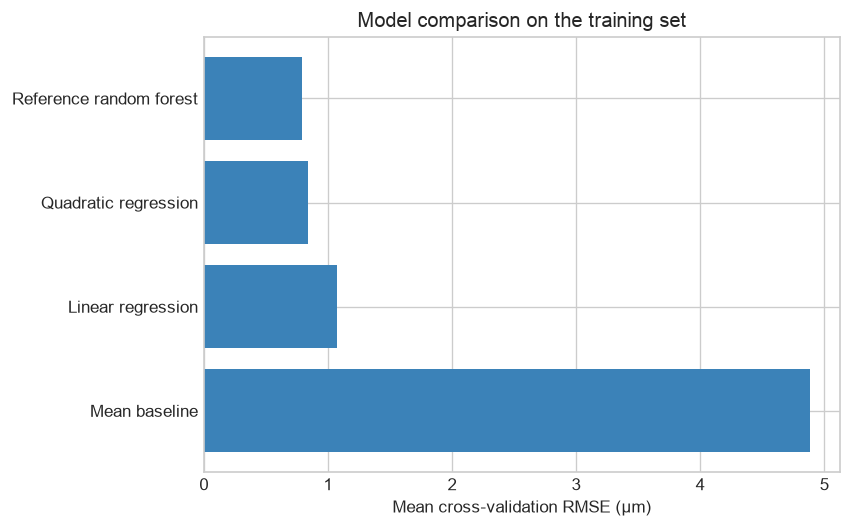

In [7]:
fig, ax = plt.subplots(figsize=(7.2, 4.5))
ordered = cv_results.sort_values('RMSE_mean_um', ascending=False)
ax.barh(ordered['model'], ordered['RMSE_mean_um'], color='#3b82b8')
ax.set_xlabel('Mean cross-validation RMSE (μm)')
ax.set_title('Model comparison on the training set')
fig.tight_layout()
fig.savefig(figure_dir / 'cv_model_comparison.png', bbox_inches='tight')
plt.show()

The random forest gives the lowest training-set cross-validation error. The linear and quadratic models remain useful references because they show how much is gained by modelling the nonlinear response.

## 3. Random forest tuning

In [8]:
parameter_grid = {
    'n_estimators': [100, 300],
    'max_depth': [None, 5, 10, 15],
    'min_samples_leaf': [1, 2, 4],
    'max_features': [1.0, 'sqrt'],
}

search = GridSearchCV(
    RandomForestRegressor(random_state=random_state, n_jobs=-1),
    param_grid=parameter_grid,
    scoring='neg_root_mean_squared_error',
    cv=cv,
    n_jobs=-1,
)
search.fit(X_train, y_train)
final_model = search.best_estimator_

print('Best parameters:', search.best_params_)
print(f'Best training CV RMSE: {-search.best_score_:.4f} μm')

Best parameters: {'max_depth': 15, 'max_features': 1.0, 'min_samples_leaf': 1, 'n_estimators': 300}
Best training CV RMSE: 0.7920 μm


In [9]:
search_results = (pd.DataFrame(search.cv_results_)
                  .sort_values('rank_test_score')
                  [['rank_test_score', 'mean_test_score', 'param_n_estimators',
                    'param_max_depth', 'param_min_samples_leaf', 'param_max_features']]
                  .head(8)
                  .copy())
search_results['CV_RMSE_um'] = -search_results['mean_test_score']
search_results.drop(columns='mean_test_score').round(4)

,rank_test_score,param_n_estimators,param_max_depth,param_min_samples_leaf,param_max_features,CV_RMSE_um
37,1,300,15,1,1.0,0.7920
1,2,300,None,1,1.0,0.7920
25,3,300,10,1,1.0,0.7920
36,4,100,15,1,1.0,0.7943
0,5,100,None,1,1.0,0.7943
24,6,100,10,1,1.0,0.7943
13,7,300,5,1,1.0,0.8474
12,8,100,5,1,1.0,0.8476


The tuning result is very close to the original 100-tree setting. The main benefit is confirming that a much more complicated forest is not necessary for this dataset.

## 4. Holdout evaluation

In [10]:
def regression_metrics(y_true, y_pred):
    return {
        'R2': r2_score(y_true, y_pred),
        'MAE_um': mean_absolute_error(y_true, y_pred),
        'RMSE_um': mean_squared_error(y_true, y_pred) ** 0.5,
    }

evaluation_models = {**models, 'Tuned random forest': final_model}
metric_rows = []
for name, model in evaluation_models.items():
    model.fit(X_train, y_train)
    metric_rows.append({'model': name, 'split': 'train',
                        **regression_metrics(y_train, model.predict(X_train))})
    metric_rows.append({'model': name, 'split': 'test',
                        **regression_metrics(y_test, model.predict(X_test))})

model_metrics = pd.DataFrame(metric_rows)
model_metrics.to_csv(result_dir / 'model_metrics.csv', index=False)
model_metrics.round(4)

,model,split,R2,MAE_um,RMSE_um
0,Mean baseline,train,0.0000,4.0953,4.8340
1,Mean baseline,test,-0.0153,4.9683,5.8174
2,Linear regression,train,0.9530,0.7850,1.0485
3,Linear regression,test,0.9740,0.7352,0.9317
4,Quadratic regression,train,0.9727,0.6245,0.7980
5,Quadratic regression,test,0.9720,0.7783,0.9668
6,Reference random forest,train,0.9967,0.2048,0.2786
7,Reference random forest,test,0.9820,0.6160,0.7743
8,Tuned random forest,train,0.9969,0.2035,0.2711
9,Tuned random forest,test,0.9814,0.6373,0.7864


In [11]:
test_prediction = final_model.predict(X_test)
test_results = X_test.copy()
test_results['measured_depth_um'] = y_test
test_results['predicted_depth_um'] = test_prediction
test_results['residual_um'] = y_test - test_prediction
test_results['absolute_error_um'] = test_results['residual_um'].abs()
test_results = test_results.sort_values('absolute_error_um', ascending=False)
test_results.to_csv(result_dir / 'test_predictions.csv', index=False)
test_results.head(8).round(4)

,voltage_V,pulses,measured_depth_um,predicted_depth_um,residual_um,absolute_error_um
44,500,150,28.7350,27.2235,1.5115,1.5115
104,580,150,31.2222,29.7608,1.4614,1.4614
47,520,30,13.8910,15.2113,-1.3203,1.3203
88,560,140,29.6039,28.3091,1.2948,1.2948
31,500,20,13.8214,12.5988,1.2225,1.2225
89,560,150,30.3545,29.1339,1.2206,1.2206
73,540,140,28.5103,27.6108,0.8995,0.8995
65,540,60,19.2412,18.5558,0.6854,0.6854


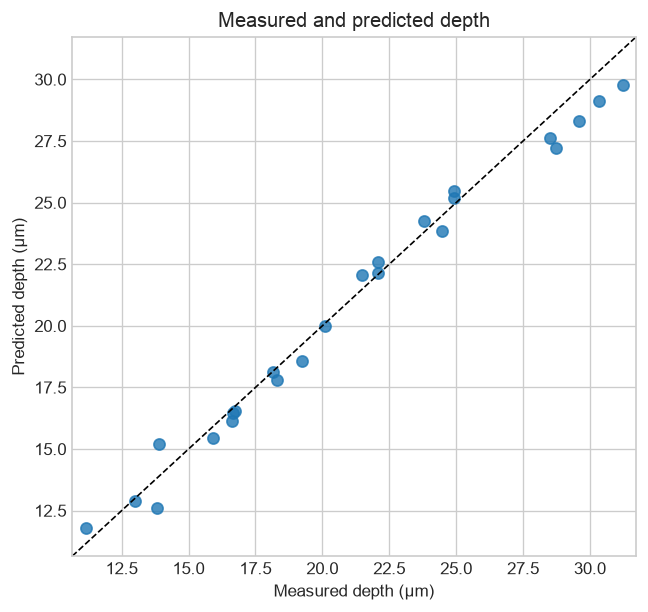

In [12]:
fig, ax = plt.subplots(figsize=(5.5, 5.2))
ax.scatter(y_test, test_prediction, s=45, alpha=0.8)
limits = [min(y_test.min(), test_prediction.min()) - 0.5,
          max(y_test.max(), test_prediction.max()) + 0.5]
ax.plot(limits, limits, '--', color='black', lw=1)
ax.set(xlim=limits, ylim=limits, xlabel='Measured depth (μm)',
       ylabel='Predicted depth (μm)', title='Measured and predicted depth')
fig.tight_layout()
fig.savefig(figure_dir / 'predicted_vs_actual.png', bbox_inches='tight')
plt.show()

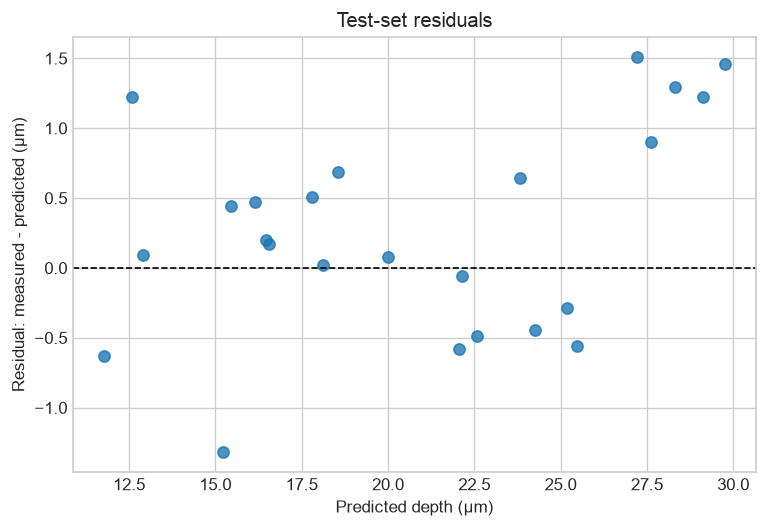

In [13]:
fig, ax = plt.subplots(figsize=(6.5, 4.5))
ax.scatter(test_prediction, y_test - test_prediction, s=45, alpha=0.8)
ax.axhline(0, color='black', linestyle='--', lw=1)
ax.set_xlabel('Predicted depth (μm)')
ax.set_ylabel('Residual: measured - predicted (μm)')
ax.set_title('Test-set residuals')
fig.tight_layout()
fig.savefig(figure_dir / 'residuals.png', bbox_inches='tight')
plt.show()

The reproduced test result is close to the thesis result, but not numerically identical. The thesis records the split seed but does not state the random forest seed or software version, so this notebook fixes both for reproducibility.

## 5. Feature importance

In [14]:
permutation = permutation_importance(
    final_model, X_test, y_test, n_repeats=30,
    random_state=random_state, scoring='r2'
)
positive_permutation = np.maximum(permutation.importances_mean, 0)
importance = pd.DataFrame({
    'feature': features,
    'impurity_fraction': final_model.feature_importances_,
    'permutation_R2_drop': permutation.importances_mean,
    'permutation_std': permutation.importances_std,
    'permutation_fraction': positive_permutation / positive_permutation.sum(),
})
importance.to_csv(result_dir / 'feature_importance.csv', index=False)
importance.round(4)

,feature,impurity_fraction,permutation_R2_drop,permutation_std,permutation_fraction
0,voltage_V,0.1189,0.1795,0.0443,0.0955
1,pulses,0.8811,1.7004,0.3603,0.9045


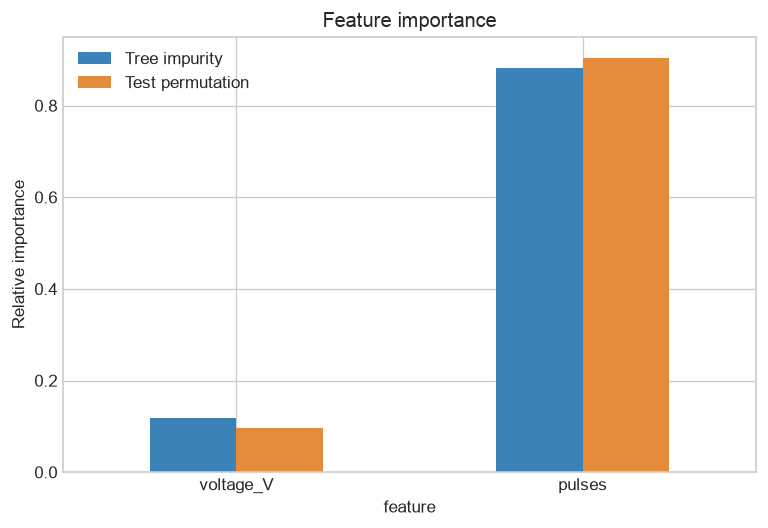

In [15]:
plot_importance = importance.set_index('feature')[['impurity_fraction', 'permutation_fraction']]
ax = plot_importance.plot(kind='bar', figsize=(6.5, 4.5), rot=0, color=['#3b82b8', '#e58b3a'])
ax.set_ylabel('Relative importance')
ax.set_title('Feature importance')
ax.legend(['Tree impurity', 'Test permutation'])
fig = ax.get_figure()
fig.tight_layout()
fig.savefig(figure_dir / 'feature_importance.png', bbox_inches='tight')
plt.show()

Both importance methods identify pulse count as the main predictor. This agrees with the stronger pulse-depth relationship observed in the experiment.

## 6. Robustness checks

In [16]:
group_rows = []
for label, groups, folds in [
    ('Unseen voltage levels', data['voltage_V'], 4),
    ('Unseen pulse levels', data['pulses'], 5),
]:
    grouped_cv = GroupKFold(n_splits=folds)
    scores = cross_validate(
        final_model, X, y, groups=groups, cv=grouped_cv, scoring=scoring
    )
    group_rows.append({
        'check': label,
        'R2_mean': scores['test_r2'].mean(),
        'R2_std': scores['test_r2'].std(),
        'MAE_mean_um': -scores['test_mae'].mean(),
        'RMSE_mean_um': -scores['test_rmse'].mean(),
    })

group_results = pd.DataFrame(group_rows)
group_results.to_csv(result_dir / 'grouped_validation.csv', index=False)
group_results.round(4)

,check,R2_mean,R2_std,MAE_mean_um,RMSE_mean_um
0,Unseen voltage levels,0.9438,0.0154,0.9599,1.1579
1,Unseen pulse levels,0.9096,0.0482,1.1449,1.3834


Grouped validation is harder than a random point split because complete voltage or pulse levels are withheld. The lower grouped scores show that the random holdout result should not be treated as universal accuracy.

In [17]:
voltage_values = np.sort(data['voltage_V'].unique())
pulse_values = np.sort(data['pulses'].unique())
experimental_grid = pd.MultiIndex.from_product(
    [voltage_values, pulse_values], names=features
).to_frame(index=False)
experimental_grid['predicted_depth_um'] = final_model.predict(experimental_grid[features])
prediction_table = experimental_grid.pivot(
    index='voltage_V', columns='pulses', values='predicted_depth_um'
)

voltage_drops = int((np.diff(prediction_table.values, axis=0) < 0).sum())
pulse_drops = int((np.diff(prediction_table.values, axis=1) < 0).sum())
consistency = pd.DataFrame([
    {'direction': 'increasing voltage', 'comparisons': 105, 'local_drops': voltage_drops},
    {'direction': 'increasing pulses', 'comparisons': 112, 'local_drops': pulse_drops},
])
consistency['non_decreasing_fraction'] = 1 - consistency['local_drops'] / consistency['comparisons']
consistency.to_csv(result_dir / 'physical_consistency.csv', index=False)
consistency.round(4)

,direction,comparisons,local_drops,non_decreasing_fraction
0,increasing voltage,105,1,0.9905
1,increasing pulses,112,1,0.9911


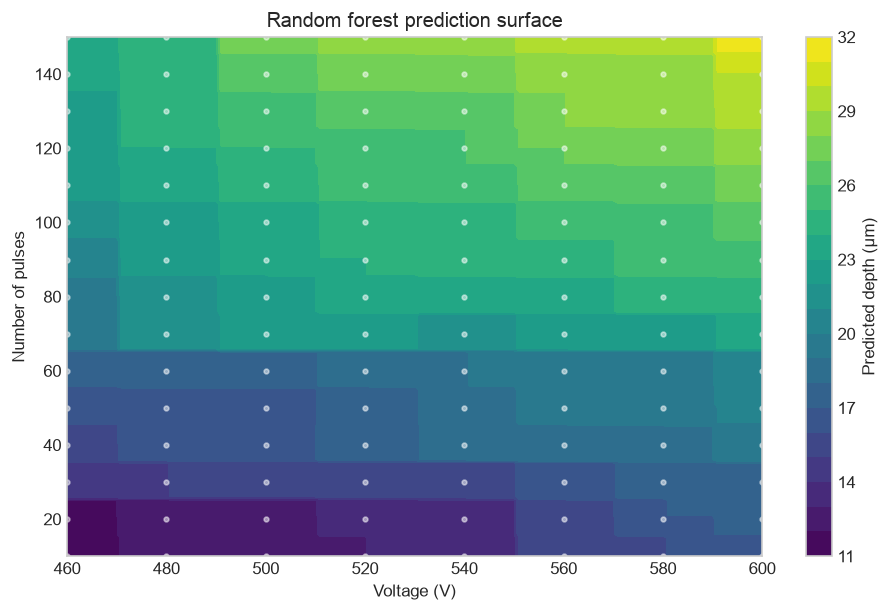

In [18]:
voltage_grid, pulse_grid = np.meshgrid(
    np.linspace(460, 600, 141),
    np.linspace(10, 150, 141),
)
surface_points = pd.DataFrame({
    'voltage_V': voltage_grid.ravel(),
    'pulses': pulse_grid.ravel(),
})
surface_depth = final_model.predict(surface_points).reshape(voltage_grid.shape)

fig, ax = plt.subplots(figsize=(8, 5.2))
contour = ax.contourf(voltage_grid, pulse_grid, surface_depth, levels=20, cmap='viridis')
ax.scatter(data['voltage_V'], data['pulses'], s=8, c='white', alpha=0.5)
ax.set_xlabel('Voltage (V)')
ax.set_ylabel('Number of pulses')
ax.set_title('Random forest prediction surface')
fig.colorbar(contour, ax=ax, label='Predicted depth (μm)')
fig.tight_layout()
fig.savefig(figure_dir / 'prediction_surface.png', bbox_inches='tight')
plt.show()

## 7. Conclusions

- The tuned forest reaches a test R² of about 0.981 and a test RMSE of about 0.79 μm.
- Tuning changes the result only slightly, so model complexity is not the main limitation.
- Pulse count is the dominant feature, consistent with cumulative multi-pulse ablation.
- Grouped validation is weaker than the random split, especially when complete pulse levels are withheld.
- Predictions are almost monotonic on the measured parameter grid, but a few small local drops remain.
- The model should only be used within 460–600 V and 10–150 pulses.